In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv(
    r"C:\Users\mkart\OneDrive\Desktop\credit-risk-ai\master_v6.csv"
)

# Drop leakage/non-predictive columns
drop_cols = [
    "student_id",
    "default_probability",
    "dataset_split"
]

df = df.drop(columns=drop_cols)

# Optional: remove multicollinearity features flagged in EDA
df = df.drop(
    columns=[
        "synthetic_age",
        "remaining_semesters",
        "expected_total_semesters"
    ],
    errors="ignore"
)

# Encode categorical columns
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Features and target
X = df.drop("default_flag", axis=1)
y = df["default_flag"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Model
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob))

Before SMOTE:
default_flag
0    16254
1      546
Name: count, dtype: int64

After SMOTE:
default_flag
0    16254
1    16254
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4064
           1       0.29      0.21      0.24       136

    accuracy                           0.96      4200
   macro avg       0.63      0.59      0.61      4200
weighted avg       0.95      0.96      0.95      4200


ROC-AUC:
0.7734574021537749


<Figure size 1000x800 with 0 Axes>

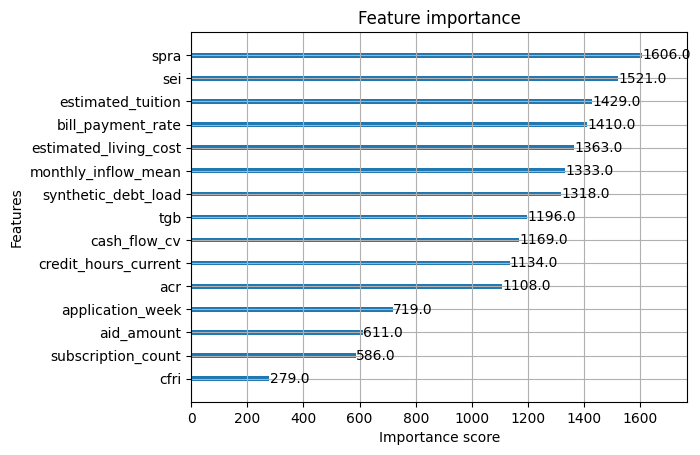

In [7]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10,8))
plot_importance(model, max_num_features=15)
plt.show()

In [8]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

ModuleNotFoundError: No module named 'torch'

In [5]:
scale_pos_weight = (
    len(y_train[y_train == 0])
    /
    len(y_train[y_train == 1])
)

print(scale_pos_weight)

29.76923076923077
